# Decision Tree 

## Install python packages and import
Python Kernal: 3.12.8

In [1]:
%pip install -upgrade pip
%pip install xgboost pandas scikit-learn


Note: you may need to restart the kernel to use updated packages.



Usage:   
  d:\TECH\AI\envs\py312-nlp\python.exe -m pip install [options] <requirement specifier> [package-index-options] ...
  d:\TECH\AI\envs\py312-nlp\python.exe -m pip install [options] -r <requirements file> [package-index-options] ...
  d:\TECH\AI\envs\py312-nlp\python.exe -m pip install [options] [-e] <vcs project url> ...
  d:\TECH\AI\envs\py312-nlp\python.exe -m pip install [options] [-e] <local project path> ...
  d:\TECH\AI\envs\py312-nlp\python.exe -m pip install [options] <archive url/path> ...

no such option: -u


Note: you may need to restart the kernel to use updated packages.


In [40]:
# import libraries
import pandas as pd # Pandas for data manipulation
import seaborn as sns # Seaboarn for data visualization
import matplotlib.pyplot as plt # Matplotlib for plotting
import numpy as np # Numpy for numerical operations

from sklearn import tree #  Import Decision Tree Classifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV # Import train_test_split and RandomizedSearchCV for model evaluation and hyperparameter tuning
from sklearn.ensemble import RandomForestClassifier # Import Random Forest Classifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder # Import LabelEncoder and OrdinalEncoder for encoding categorical variables
from sklearn.pipeline import Pipeline # Import Pipeline for creating machine learning pipelines
from sklearn.impute import SimpleImputer # Import SimpleImputer for handling missing values
from sklearn.compose import ColumnTransformer # Import ColumnTransformer for applying different transformations to different columns
from sklearn import metrics # Import metrics for model evaluation
from scipy.stats import randint # Import randint for random integer generation in hyperparameter tuning
from xgboost import XGBClassifier, plot_importance # Import XGBClassifier and plot_importance for XGBoost model and feature importance visualization


## Load Dataset

In [41]:
df = pd.read_csv('train_data.csv')
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,410704,0,Cash loans,F,N,Y,1,157500.0,900000.0,26446.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,381230,0,Cash loans,F,N,Y,1,90000.0,733176.0,21438.0,...,0,0,0,0,0.0,0.0,0.0,0.0,2.0,1.0
2,450177,0,Cash loans,F,Y,Y,0,189000.0,1795500.0,62541.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,332445,0,Cash loans,M,Y,N,0,175500.0,494550.0,45490.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,357429,0,Cash loans,F,Y,Y,0,270000.0,1724688.0,54283.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
# Lets select the features based on previous assignment.
selected_features = [
    # Stronger negative correlation
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "DAYS_EMPLOYED",
    "AMT_GOODS_PRICE",
    "REGION_POPULATION_RELATIVE",
    "AMT_CREDIT",
    "AMT_ANNUITY",

    # Positive correlation
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "LIVE_CITY_NOT_WORK_CITY",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "DAYS_REGISTRATION",
    "REG_CITY_NOT_LIVE_CITY",
    "FLAG_EMP_PHONE",
    "DAYS_ID_PUBLISH",
    "REG_CITY_NOT_WORK_CITY",
    "DAYS_LAST_PHONE_CHANGE",
    "REGION_RATING_CLIENT",
    "REGION_RATING_CLIENT_W_CITY",
    "DAYS_BIRTH",
    "AMT_INCOME_TOTAL",

    # Others
    "CODE_GENDER",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "TARGET"
    
]

### Keep only rows with non-null target values
df = df[df['TARGET'].notnull().copy()]

### Define features and target dataframes
df = df[selected_features]
df.head()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_EMPLOYED,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,AMT_CREDIT,AMT_ANNUITY,CNT_CHILDREN,CNT_FAM_MEMBERS,...,DAYS_BIRTH,AMT_INCOME_TOTAL,CODE_GENDER,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,TARGET
0,NaN,0.397762,0.177704,-2037,900000.0,0.010006,900000.0,26446.5,1,3.0,...,-16180,157500.0,F,Working,Secondary / secondary special,NaN,Business Entity Type 3,Married,House / apartment,0
1,0.697782,0.696312,0.538863,-162,612000.0,0.031329,733176.0,21438.0,1,2.0,...,-14969,90000.0,F,Working,Higher education,Accountants,Bank,Single / not married,House / apartment,0
2,NaN,0.716972,0.355639,365243,1795500.0,0.028663,1795500.0,62541.0,0,2.0,...,-22213,189000.0,F,Pensioner,Secondary / secondary special,NaN,XNA,Married,House / apartment,0
3,NaN,0.662210,0.085033,365243,450000.0,0.004960,494550.0,45490.5,0,2.0,...,-19301,175500.0,M,Pensioner,Higher education,NaN,XNA,Married,House / apartment,0
4,NaN,0.774506,0.627991,-886,1575000.0,0.018850,1724688.0,54283.5,0,2.0,...,-18409,270000.0,F,Working,Higher education,Core staff,Self-employed,Married,House / apartment,0


In [43]:
### Convert all DAYS columns like DAYS_EMPLOYED, DAYS_BIRTH etc
### Negative Days to years. 
days_cols = [col for col in df.columns if "DAYS" in col]

for col in days_cols:
   df[col] = df[col].abs()

if "DAYS_BIRTH" in df.columns:
   df["AGE_YEAS"] = df["DAYS_BIRTH"] / 365

### Employment ratio = DAYS_EMPLOYED / DAYS_BIRTH
### Higher ratio means stable work experience.  
if "DAYS_EMPLOYED" in df.columns and "DAYS_BIRTH" in df.columns:
   df["EMPLOYMENT_RATION"] = df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"]

### Convert Credit and amount annuality to ration
### This ratio can provide insights into the financial burden of the credit compared to the annuity payments. 
### A higher ratio may indicate a larger credit amount relative to the annuity, which could be a risk factor for default.
if "AMT_CREDIT" in df.columns and "AMT_ANNUITY" in df.columns:
   df["CREDIT_ANNUITY_RATIO"] = (
    df["AMT_CREDIT"] / (df["AMT_ANNUITY"] + 1)
   )

### Goods product price to credit ratio.
### This ratio can provide insights into the relationship between the price of goods and the credit amount.
if "AMT_GOODS_PRICE" in df.columns and "AMT_CREDIT" in df.columns:
   df["GOODS_PRICE_CREDIT_RATIO"] = (
    df["AMT_GOODS_PRICE"] / (df["AMT_CREDIT"] + 1)
   )

### Children to family members ratio.
### This ratio can provide insights into the family structure and potential financial responsibilities of the applicant.
if "CNT_CHILDREN" in df.columns and "CNT_FAM_MEMBERS" in df.columns:
   df["CHILDREN_FAMILY_RATIO"] = (
    df["CNT_CHILDREN"] / (df["CNT_FAM_MEMBERS"] + 1)
   )

### replace infinite values with NaN
df = df.replace([np.inf, -np.inf], np.nan)

df.head()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_EMPLOYED,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,AMT_CREDIT,AMT_ANNUITY,CNT_CHILDREN,CNT_FAM_MEMBERS,...,OCCUPATION_TYPE,ORGANIZATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,TARGET,AGE_YEAS,EMPLOYMENT_RATION,CREDIT_ANNUITY_RATIO,GOODS_PRICE_CREDIT_RATIO,CHILDREN_FAMILY_RATIO
0,NaN,0.397762,0.177704,2037,900000.0,0.010006,900000.0,26446.5,1,3.0,...,NaN,Business Entity Type 3,Married,House / apartment,0,44.328767,0.125896,34.029681,0.999999,0.250000
1,0.697782,0.696312,0.538863,162,612000.0,0.031329,733176.0,21438.0,1,2.0,...,Accountants,Bank,Single / not married,House / apartment,0,41.010959,0.010822,34.198237,0.834723,0.333333
2,NaN,0.716972,0.355639,365243,1795500.0,0.028663,1795500.0,62541.0,0,2.0,...,NaN,XNA,Married,House / apartment,0,60.857534,16.442759,28.708708,0.999999,0.000000
3,NaN,0.662210,0.085033,365243,450000.0,0.004960,494550.0,45490.5,0,2.0,...,NaN,XNA,Married,House / apartment,0,52.879452,18.923527,10.871262,0.909916,0.000000
4,NaN,0.774506,0.627991,886,1575000.0,0.018850,1724688.0,54283.5,0,2.0,...,Core staff,Self-employed,Married,House / apartment,0,50.435616,0.048129,31.771279,0.913208,0.000000


### Encode categorical columns

In [46]:
## Encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("\nCategorical Columns:", categorical_cols)
print("\nNumerical Columns:", numerical_cols)


Categorical Columns: ['CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']

Numerical Columns: ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_EMPLOYED', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'AMT_CREDIT', 'AMT_ANNUITY', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'LIVE_CITY_NOT_WORK_CITY', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DAYS_REGISTRATION', 'REG_CITY_NOT_LIVE_CITY', 'FLAG_EMP_PHONE', 'DAYS_ID_PUBLISH', 'REG_CITY_NOT_WORK_CITY', 'DAYS_LAST_PHONE_CHANGE', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'DAYS_BIRTH', 'AMT_INCOME_TOTAL', 'TARGET', 'AGE_YEAS', 'EMPLOYMENT_RATION', 'CREDIT_ANNUITY_RATIO', 'GOODS_PRICE_CREDIT_RATIO', 'CHILDREN_FAMILY_RATIO']


In [48]:
# CODE_GENDER, NAME_INCOME_TYPE, NAME_EDUCATION_TYPE, OCCUPATION_TYPE, ORGANIZATION_TYPE
sdf = df.copy()
sdf['CODE_GENDER'] = sdf['CODE_GENDER'].map({'M': 0, 'F': 1, 'XNA': np.nan})  # Map 'M' to 0, 'F' to 1, and 'XNA' to NaN
education_mapping = {
    'Lower secondary': 0,
    'Secondary / secondary special': 1,
    'Incomplete higher': 2,
    'Higher education': 3,
    'Academic degree': 4
}
sdf['NAME_EDUCATION_TYPE'] = sdf['NAME_EDUCATION_TYPE'].map(education_mapping)
label_encoders = [
    'NAME_INCOME_TYPE',
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE'
]
for col in label_encoders:
    le = LabelEncoder()
    mask = sdf[col].notnull()
    sdf.loc[mask, col] = le.fit_transform(sdf.loc[mask, col])                                        
    sdf[col] = pd.to_numeric(sdf[col], errors='coerce').astype('Int64')  
    
    
# Verify
print('There are no object columns:', sdf.select_dtypes(include=['object']).columns.tolist())
print('\nShape:', sdf.shape)

There are no object columns: []

Shape: (153755, 36)


In [49]:
sdf.head()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_EMPLOYED,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,AMT_CREDIT,AMT_ANNUITY,CNT_CHILDREN,CNT_FAM_MEMBERS,...,OCCUPATION_TYPE,ORGANIZATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,TARGET,AGE_YEAS,EMPLOYMENT_RATION,CREDIT_ANNUITY_RATIO,GOODS_PRICE_CREDIT_RATIO,CHILDREN_FAMILY_RATIO
0,NaN,0.397762,0.177704,2037,900000.0,0.010006,900000.0,26446.5,1,3.0,...,<NA>,5,1,1,0,44.328767,0.125896,34.029681,0.999999,0.250000
1,0.697782,0.696312,0.538863,162,612000.0,0.031329,733176.0,21438.0,1,2.0,...,0,2,3,1,0,41.010959,0.010822,34.198237,0.834723,0.333333
2,NaN,0.716972,0.355639,365243,1795500.0,0.028663,1795500.0,62541.0,0,2.0,...,<NA>,57,1,1,0,60.857534,16.442759,28.708708,0.999999,0.000000
3,NaN,0.662210,0.085033,365243,450000.0,0.004960,494550.0,45490.5,0,2.0,...,<NA>,57,1,1,0,52.879452,18.923527,10.871262,0.909916,0.000000
4,NaN,0.774506,0.627991,886,1575000.0,0.018850,1724688.0,54283.5,0,2.0,...,3,42,1,1,0,50.435616,0.048129,31.771279,0.913208,0.000000


### Split dataset for training and testing

In [50]:
### Define features and target dataframes
X = sdf.drop(columns=['TARGET'])
y = sdf['TARGET']

### Split the data into training and testing sets
### 70% training and 30% testing split with random state of 1 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)


# 1. Single Classification tree

**With Max depth 10**

In [59]:
sclf = tree.DecisionTreeClassifier(max_depth=10)   # Create a Decision Tree Classifier
sclf = sclf.fit(X_train, y_train)      # Fit the model to the training data    
y_hat = sclf.predict(X_train)          # Predict the target values for the training set
y_pred = sclf.predict(X_test)          # Predict the target values for the testing set

print("Training Accuracy:", metrics.accuracy_score(y_train, y_hat)) # Print the training accuracy
print("Testing Accuracy:", metrics.accuracy_score(y_test, y_pred)) # Print the testing accuracy

Training Accuracy: 0.9265804437506968
Testing Accuracy: 0.9123723632579617


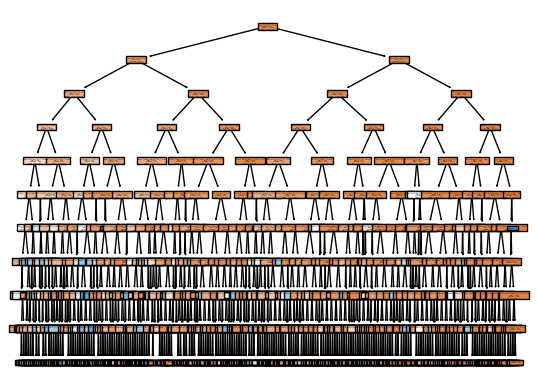

In [60]:
### Visualizing the single class decision tree
f_names=list(X.columns)
tree.plot_tree(sclf, filled=True, feature_names=f_names) # Plot the decision tree with filled nodes and feature names
plt.show()

**With Max depth 4, min_samples_leaf=3, criterion="entropy"**

In [68]:
sclf = tree.DecisionTreeClassifier(max_depth=4, min_samples_leaf=3, criterion='entropy')   # Create a Decision Tree Classifier
sclf = sclf.fit(X_train, y_train)      # Fit the model to the training data    
y_hat = sclf.predict(X_train)          # Predict the target values for the training set
y_pred = sclf.predict(X_test)          # Predict the target values for the testing set

print("Training Accuracy:", metrics.accuracy_score(y_train, y_hat)) # Print the training accuracy
print("Testing Accuracy:", metrics.accuracy_score(y_test, y_pred)) # Print the testing accuracy

Training Accuracy: 0.9201694726279407
Testing Accuracy: 0.9171851627029722


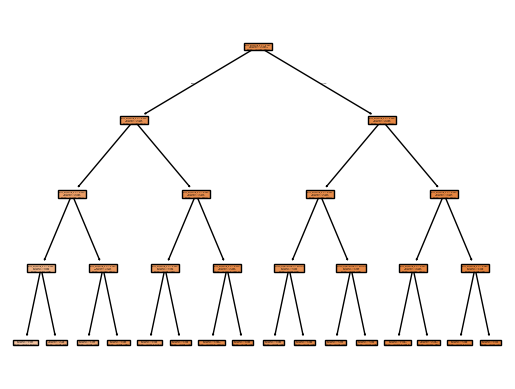

In [69]:
### Visualizing the single class decision tree
f_names=list(X.columns)
tree.plot_tree(sclf, filled=True, feature_names=f_names) # Plot the decision tree with filled nodes and feature names
plt.show()

#### Better visualization

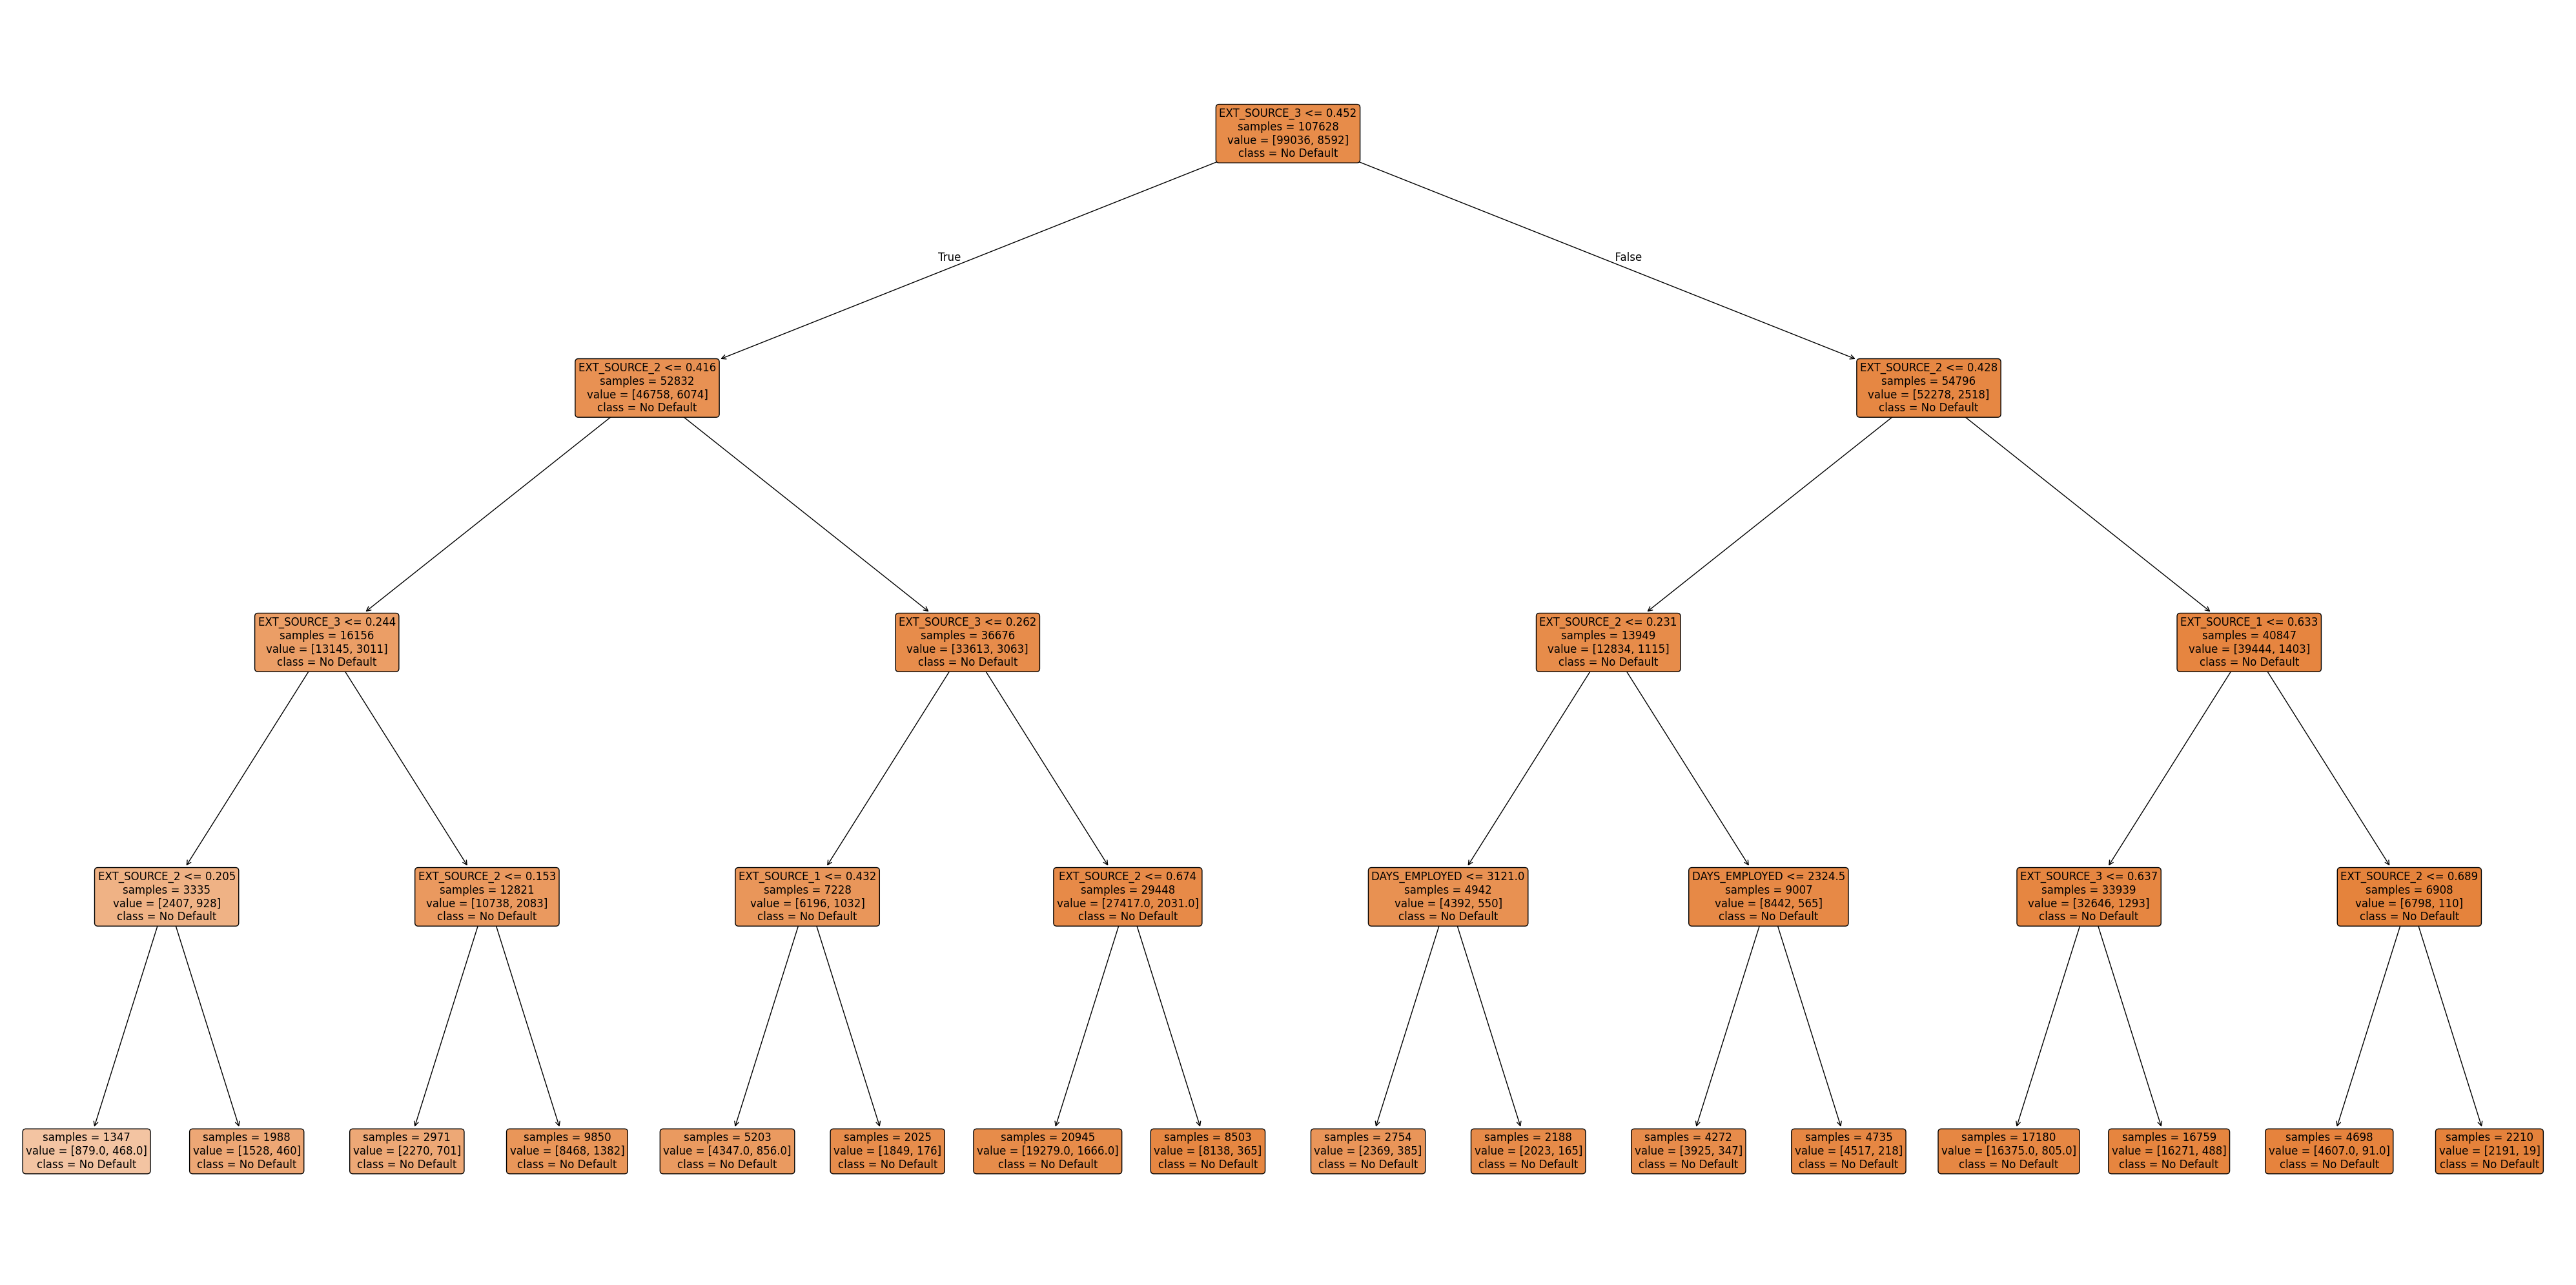

In [70]:
plt.figure(figsize=(40, 20))   # bigger canvas so nodes have room
tree.plot_tree(
    sclf,
    feature_names=list(X.columns),
    class_names=['No Default', 'Default'],
    filled=True,
    rounded=True,
    fontsize=12,          # increase from default (~8)
    impurity=False,       # remove gini line to reduce clutter
    proportion=False,
)
plt.tight_layout()
plt.savefig('tree.png', dpi=150, bbox_inches='tight')
plt.show()

- The plot is readable now.
- The rool split on **EXT_SOURCE_3** is valid as it stongest negative correlator
- EXT_SOURCE_1, EXT_SOURCE_2, DAYS_EMPLOYED appearing repeatedly confirms your feature selection is correct
- The model is likely just predicting the majority class almost always, which inflates accuracy. A 92% accuracy on an imbalanced dataset is misleading.

# 2. RandomForest Model

In [71]:
rf = RandomForestClassifier(n_estimators=100, random_state=100)
rf = rf.fit(X_train, y_train)      # Fit the model to the training data
y_hat_rf = rf.predict(X_train)     # Predict the target values for the training set
y_pred_rf = rf.predict(X_test)     # Predict the target values for the testing set

print("Random Forest Training Accuracy:", metrics.accuracy_score(y_train, y_hat_rf)) # Print the training accuracy
print("Random Forest Testing Accuracy:", metrics.accuracy_score(y_test, y_pred_rf)) # Print the testing accuracy

Random Forest Training Accuracy: 0.9999814174750065
Random Forest Testing Accuracy: 0.9174236347475448


#### Visualizing RF trees

In [72]:
f_names=list(X.columns) # Feature names
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10,2), dpi=3000) # Setup the 1x5 grid for ploting the trees
for index in range(0, 5): # Iterate through the first five trees (of 100)
  tree.plot_tree(rf.estimators_[index], feature_names=f_names, filled = True, ax=axes[index]); # Plot the tree
  axes[index].set_title('Estimator: ' + str(index), fontsize = 11) # Print title

In [73]:
#@title Hyperparameter search
param_dist = {'n_estimators': randint(50,500), 'max_depth': randint(1,20)} # Search ranges
rf = RandomForestClassifier() # Create a random forest classifier
rand_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=5, cv=5) # Use random search to find the best hyperparameters
rand_search.fit(X_train, y_train) # Fit the random search object to the training data

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

best_rf = rand_search.best_estimator_ # Capture the best model
y_hat = best_rf.predict(X_train) # Predict the response for train dataset
y_pred = best_rf.predict(X_test) # Predict the response for test dataset

# Compute training and test accuracy
print("Train Accuracy:", metrics.accuracy_score(y_train, y_hat))
print("Test Accuracy:", metrics.accuracy_score(y_test, y_pred))

Best hyperparameters: {'max_depth': 18, 'n_estimators': 490}
Train Accuracy: 0.9477923960307727
Test Accuracy: 0.9173585969172069


Precision: 0.8994445563531844
Recall: 0.9173585969172069


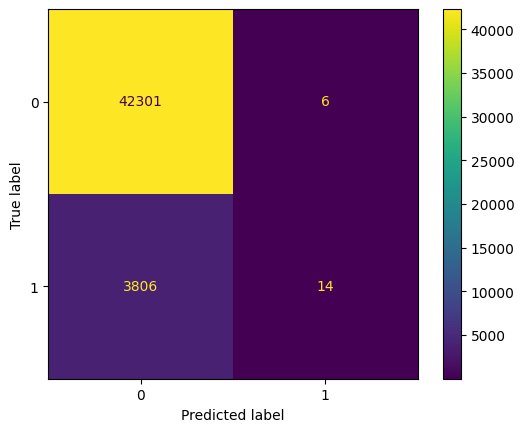

In [74]:
#@title More Evaluation Metrics

print("Precision:", metrics.precision_score(y_test, y_pred, average = 'weighted')) # Note - multi-class problem so not straight forward!
print("Recall:", metrics.recall_score(y_test, y_pred, average = 'weighted')) # Note - multi-class problem so not straight forward!

# Create the confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)
metrics.ConfusionMatrixDisplay(confusion_matrix=cm).plot();

Random Forest is the better model architecturally bagging reduces variance, tuned hyperparameters.


## 3. Comparision - single Decision tree vs RandomForest

| Metric | Decision Tree | Random Forest |
|---|---|---|
| **Configuration** | max_depth=4 · entropy · min_samples_leaf=3 | n_estimators=100+tuned · RandomizedSearchCV · 5-fold CV |
| **Train accuracy** | ~92.0% | Higher (likely ~99%) |
| **Test accuracy** | ~91.7% | Higher than DT |
| **Train/test gap** | ~0.3% (low) | Likely wider (overfitting risk) |
| **Trees used** | 1 | 100 (tuned) |
| **Hyperparameter tuning** | Manual | RandomizedSearchCV |
| **Interpretability** | High | Low (black box) |
| **Training speed** | Fast (0.3s) | Slow (2m 22s) |
| **Issues** | - Accuracy inflated by class imbalance (~92% majority class) <br> - All leaf nodes predict "No Default" — minority class ignored <br> - No recall/precision/ROC-AUC reported <br> - Earlier run with max_depth=10 used (not shown here) | - n_iter=5 in RandomizedSearchCV is too low — increase to 20+ |
| **Strengths** | — | - Reduces variance via bagging — more robust than single tree <br> - Confusion matrix + precision/recall reported <br> - Cross-validated hyperparameter search |